In [1]:
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
import sys

sys.path.append('/Users/hedge/dev/boats')

from boats.lib.common import *
from boats.lib.boat import Boat



In [2]:
boatname = 'Petsamo'

sails = ['Nr.1', 'Nr.2', 'Nr.3', 'Stormjib', 'Mainsail', 'Genaker', 'Mizzen', 'Mizzen staysail']
points_of_sail={
    'close haul': list(range(0,37)),
    'close reach': list(range(36,73)),
    'beam': list(range(72,109)),
    'broad reach': list(range(108,145)),
    'run': list(range(144,181))
}
yesmark = 'x'
nomark = '-'

In [3]:
boat=Boat(boatname)

In [4]:
boat.log.load()
df=boat.log.df
#df.dropna(inplace=True)
df['heel']=df['heel'].apply(lambda x: int(abs(x)))
df['twd']=df['twd'].apply(lambda x: round(x,0))
df['twa']=df['twa'].apply(lambda x: abs(x))
df=df[df['spd']!=0]
df.head()

,tws,spd,twd,twa,awa,heel,lat,lon,sails,hdg
2024-10-08 00:11:39.603251934,15.7,4.4,71,54,43.0,27,44.44315,-60.33986,"[Mainsail, Mizzen, Nr.3]",NaN
2024-10-08 00:12:08.685408115,15.7,4.4,71,54,43.0,27,44.44315,-60.33986,"[Mainsail, Mizzen, Nr.3]",NaN
2024-10-08 00:12:43.100683928,15.7,4.4,71,54,43.0,27,44.44315,-60.33986,"[Mainsail, Mizzen, Nr.3]",NaN
2024-10-08 00:17:00.234331846,15.7,4.4,71,54,43.0,27,44.44315,-60.33986,"[Mainsail, Mizzen, Nr.3]",NaN
2024-10-08 00:18:40.694143057,15.7,4.4,71,54,43.0,27,44.44315,-60.33986,"[Mainsail, Mizzen, Nr.3]",NaN


In [5]:
len(df)

2718

In [6]:
df.index[-1].strftime('%d-%b-%y %H:%M')

'16-Mar-25 22:51'

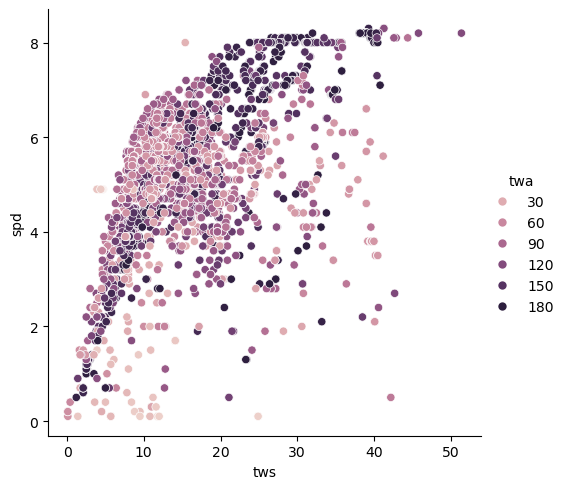

In [7]:
sns.relplot(df, x='tws', y='spd', hue='twa')

<Axes: xlabel='tws', ylabel='spd'>

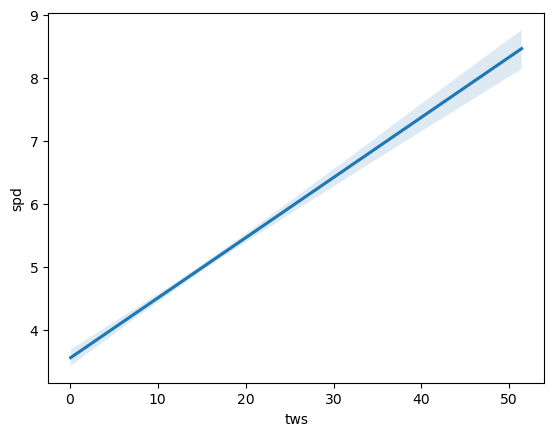

In [8]:
sns.regplot(df, x='tws', y='spd', scatter=False)

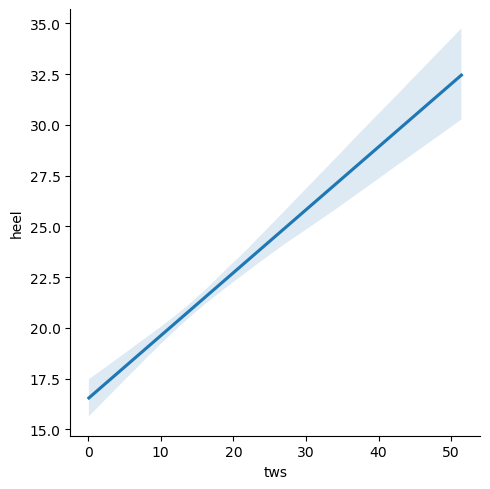

In [9]:
sns.lmplot(df, x='tws', y='heel', scatter=False)

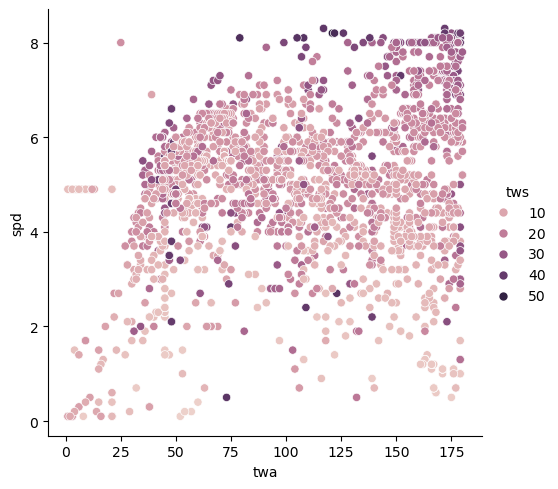

In [10]:
sns.relplot(df, x='twa', y='spd', hue='tws')

<Axes: ylabel='Count'>

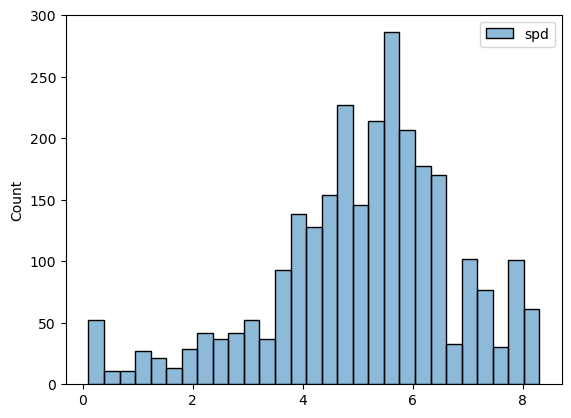

In [11]:
sns.histplot(df[['spd']])

<Axes: xlabel='tws', ylabel='Count'>

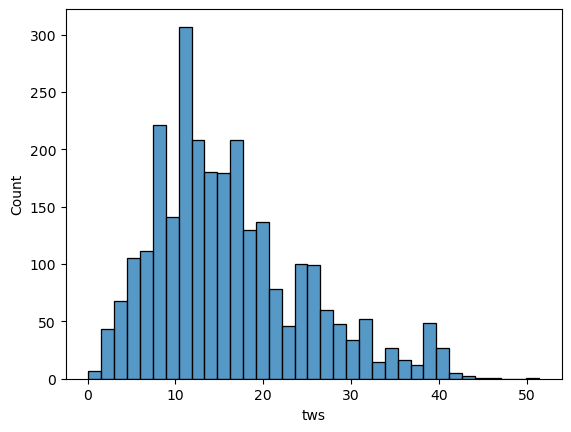

In [12]:
sns.histplot(df['tws'])

<Axes: ylabel='Count'>

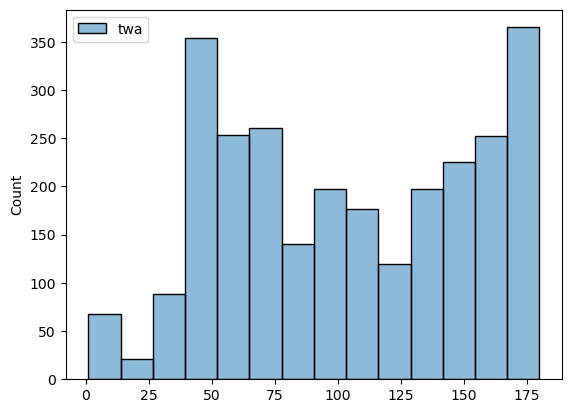

In [13]:
sns.histplot(df[['twa']])

In [51]:
df_heel=df[(df.heel<=30) & (df.spd>=5)]
df_heel

,tws,spd,twd,twa,awa,heel,lat,lon,sails,hdg
2024-10-08 22:08:13.424129963,11.6,5.5,123,45,31.0,24,45.70036,-58.89019,"[Mainsail, Mizzen, Nr.2]",NaN
2024-10-08 22:36:20.305956125,13.0,5.7,124,46,33.0,26,45.70901,-58.82980,"[Mainsail, Mizzen, Nr.2]",NaN
2024-10-08 23:14:14.780076981,14.9,5.7,125,47,34.0,30,45.72208,-58.74683,"[Mainsail, Mizzen, Nr.2]",NaN
2024-10-11 13:12:32.669096947,17.6,7.1,267,165,-155.0,20,46.59292,-52.67861,"[Mainsail, Mizzen, Genaker, Mizzen staysail, N...",NaN
2024-10-11 20:47:54.571174860,24.3,5.2,236,123,-111.0,26,47.08148,-52.62083,"[Mizzen, Nr.2]",NaN
...,...,...,...,...,...,...,...,...,...,...
2025-03-13 16:07:32.175985813,22.8,5.5,179,83,NaN,29,-40.39577,31.09551,"[Mizzen, Nr.2]",96.0
2025-03-14 10:16:43.141283989,17.1,5.3,215,119,NaN,30,-40.44733,32.63508,"[Mainsail, Mizzen, Nr.1]",97.0
2025-03-15 16:49:26.900948048,11.9,5.8,164,49,NaN,23,-41.56909,35.39432,"[Mainsail, Mizzen, Nr.2]",115.0
2025-03-16 06:34:03.024837971,11.7,6.3,51,66,NaN,27,-42.27581,36.34144,"[Mainsail, Mizzen, Nr.1]",117.0


<Axes: xlabel='tws', ylabel='spd'>

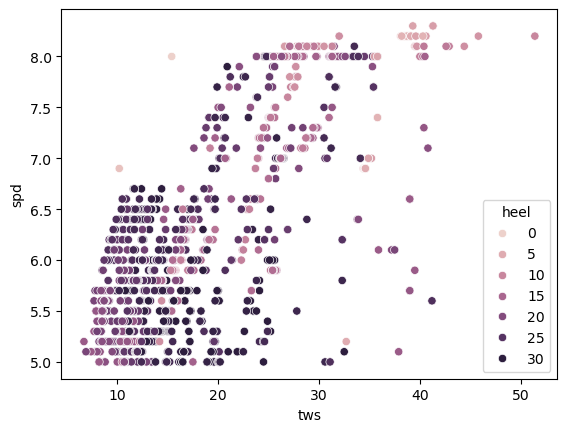

In [53]:
sns.scatterplot(df_heel, x='tws', y='spd', hue='heel')